<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-252-AI-and-Data-Engineering/blob/main/fine_tuning_InstructBLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 0) Install deps (Colab / Kaggle)
# !pip -q install -U transformers accelerate peft datasets evaluate

import os
import re
import json
import ast
import random
import numpy as np
import torch

from datasets import load_dataset, Dataset
from transformers import (
    InstructBlipProcessor,
    InstructBlipForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    default_data_collator,
)
from peft import LoraConfig, get_peft_model, TaskType

# ──────────────────────────────────────────────
# FIX ①: Mount Drive FIRST (before any training)
# so it doesn't interrupt the run mid-way
# ──────────────────────────────────────────────
# Uncomment if running on Colab:
# from google.colab import drive
# drive.mount('/content/drive')

# =============================================================
# 1) Reproducibility + config
# =============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATASET_NAME = "sujet-ai/Sujet-Finance-QA-Vision-100k"
OUT_DIR      = "/kaggle/working/instructblip_lora_out"
os.makedirs(OUT_DIR, exist_ok=True)

SAMPLE_MODE = "documents"

# FIX ②: Define ALL sampling caps in one place (were missing / duplicated)
TRAIN_DOCS   = 300     # number of source documents to sample for training
EVAL_DOCS    = 30      # number of source documents to sample for eval
MAX_TRAIN_QA = 3000    # hard cap on exploded QA pairs for training
MAX_EVAL_QA  = 300     # hard cap on exploded QA pairs for eval  (~10 %)

# Token lengths
MAX_IN_LEN     = 256
MAX_OUT_LEN    = 64

# Generation settings
NUM_BEAMS      = 3
MAX_NEW_TOKENS = 48

# =============================================================
# 2) Load dataset
# =============================================================
ds = load_dataset(DATASET_NAME)

train_docs_ds = ds["train"]
test_docs_ds  = ds["test"] if "test" in ds else None

print("Splits:", ds)
print("Train doc rows:", len(train_docs_ds))
if test_docs_ds is not None:
    print("Test doc rows:", len(test_docs_ds))

# =============================================================
# 3) Helpers: explode qa_pairs -> flat (image, question, answer)
# =============================================================
def normalize_question(q):
    return str(q).strip()

def normalize_answer(a):
    return str(a).strip()

def parse_qa_pairs(qa_pairs):
    if qa_pairs is None:
        return []
    if isinstance(qa_pairs, list):
        return qa_pairs
    if isinstance(qa_pairs, str):
        s = qa_pairs.strip()
        if not s:
            return []
        try:
            x = json.loads(s)
            return x if isinstance(x, list) else []
        except Exception:
            pass
        try:
            x = ast.literal_eval(s)
            return x if isinstance(x, list) else []
        except Exception:
            return []
    return []

def explode_docs_to_qa(doc_ds: Dataset) -> Dataset:
    rows = {"doc_id": [], "image": [], "question": [], "answer": []}
    skipped = 0

    for i, ex in enumerate(doc_ds):
        if i % 1000 == 0:
            print(f"  Processing doc {i}/{len(doc_ds)}...")

        doc_id       = ex.get("doc_id", None)
        img          = ex["image"]
        qa_pairs_raw = ex.get("qa_pairs", None)
        qa_pairs     = parse_qa_pairs(qa_pairs_raw)

        for qa in qa_pairs:
            if not isinstance(qa, dict):
                skipped += 1
                continue
            q = qa.get("question", None)
            a = qa.get("answer",   None)
            if q is None or a is None:
                skipped += 1
                continue
            q = normalize_question(q)
            a = normalize_answer(a)
            if not q or not a:
                skipped += 1
                continue

            rows["doc_id"].append(doc_id)
            rows["image"].append(img)
            rows["question"].append(q)
            rows["answer"].append(a)

    print(f"Done. Total QA rows: {len(rows['question'])} | Skipped: {skipped}")
    return Dataset.from_dict(rows)

# =============================================================
# 4) Build train / eval sets
# =============================================================
if SAMPLE_MODE == "documents":
    train_doc_sample = train_docs_ds.shuffle(seed=SEED).select(
        range(min(TRAIN_DOCS, len(train_docs_ds)))
    )

    if test_docs_ds is not None:
        eval_doc_sample = test_docs_ds.shuffle(seed=SEED).select(
            range(min(EVAL_DOCS, len(test_docs_ds)))
        )
    else:
        holdout_start   = min(TRAIN_DOCS, len(train_docs_ds))
        eval_doc_sample = train_docs_ds.shuffle(seed=SEED + 1).select(
            range(holdout_start, min(holdout_start + EVAL_DOCS, len(train_docs_ds)))
        )

    train_ds = explode_docs_to_qa(train_doc_sample)
    eval_ds  = explode_docs_to_qa(eval_doc_sample)

else:
    # FIX ③: was referencing undefined TRAIN_QA / EVAL_QA — use MAX_* caps
    full_train_qa = explode_docs_to_qa(train_docs_ds)
    full_eval_qa  = (
        explode_docs_to_qa(test_docs_ds) if test_docs_ds is not None else full_train_qa
    )

    train_ds = full_train_qa.shuffle(seed=SEED).select(
        range(min(MAX_TRAIN_QA, len(full_train_qa)))
    )
    eval_ds  = full_eval_qa.shuffle(seed=SEED + 1).select(
        range(min(MAX_EVAL_QA, len(full_eval_qa)))
    )

# Apply hard caps (relevant for "documents" mode where explode may produce many rows)
train_ds = train_ds.shuffle(seed=SEED).select(range(min(MAX_TRAIN_QA, len(train_ds))))
eval_ds  = eval_ds.shuffle(seed=SEED + 1).select(range(min(MAX_EVAL_QA, len(eval_ds))))

print("Train QA rows:", len(train_ds))
print("Eval QA rows :", len(eval_ds))
print("Unique doc_ids in train:", len(set(d for d in train_ds["doc_id"] if d is not None)))
print("Unique doc_ids in eval :", len(set(d for d in eval_ds["doc_id"]  if d is not None)))

# =============================================================
# 5) Load InstructBLIP
# =============================================================
MODEL_NAME = "Salesforce/instructblip-flan-t5-xl"
processor  = InstructBlipProcessor.from_pretrained(MODEL_NAME)

use_cuda = torch.cuda.is_available()
bf16_ok  = use_cuda and torch.cuda.is_bf16_supported()
dtype    = (
    torch.bfloat16 if bf16_ok
    else (torch.float16 if use_cuda else torch.float32)
)

model = InstructBlipForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype,
    low_cpu_mem_usage=True,
)

# Patch token ids
pad_id = processor.tokenizer.pad_token_id
eos_id = processor.tokenizer.eos_token_id

model.config.pad_token_id            = pad_id
model.generation_config.pad_token_id = pad_id

if eos_id is not None:
    model.config.eos_token_id            = eos_id
    model.generation_config.eos_token_id = eos_id

model.config.use_cache = False
model.gradient_checkpointing_enable()

if use_cuda:
    model = model.to("cuda")

# =============================================================
# 6) Add LoRA
# =============================================================
def find_lora_targets(m):
    candidates = {
        "q", "k", "v", "o",
        "query", "key", "value", "dense",
        "q_proj", "k_proj", "v_proj", "o_proj",
    }
    found = set()
    for name, module in m.named_modules():
        if isinstance(module, torch.nn.Linear):
            leaf = name.split(".")[-1]
            if leaf in candidates:
                found.add(leaf)
    return sorted(found)

targets = find_lora_targets(model)
print("LoRA targets:", targets)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    target_modules=targets,
    bias="none",
    modules_to_save=None,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# =============================================================
# 7) Preprocess (map)
# =============================================================
def preprocess_batch(batch):
    prompts = [f"Question: {q}\nAnswer:" for q in batch["question"]]

    enc = processor(
        images=batch["image"],
        text=prompts,
        padding="max_length",
        truncation=True,
        max_length=MAX_IN_LEN,
        return_tensors="pt",
    )

    labels = processor.tokenizer(
        batch["answer"],
        padding="max_length",
        truncation=True,
        max_length=MAX_OUT_LEN,
        return_tensors="pt",
    )["input_ids"]

    labels[labels == pad_id] = -100
    enc["labels"] = labels

    return {k: v.tolist() for k, v in enc.items()}

print("Mapping preprocessing ...")
train_proc = train_ds.map(preprocess_batch, batched=True, remove_columns=train_ds.column_names)
eval_proc  = eval_ds.map(preprocess_batch,  batched=True, remove_columns=eval_ds.column_names)

train_proc.set_format(type="torch")
eval_proc.set_format(type="torch")

# =============================================================
# 8) Metrics: normalized exact match + token F1
# =============================================================
VOCAB_SIZE = processor.tokenizer.vocab_size
PAD_ID     = processor.tokenizer.pad_token_id

def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s

def token_f1(pred: str, label: str) -> float:
    p_tokens = pred.split()
    l_tokens = label.split()
    if not p_tokens or not l_tokens:
        return 1.0 if p_tokens == l_tokens else 0.0
    common = set(p_tokens) & set(l_tokens)
    if not common:
        return 0.0
    precision = len(common) / len(p_tokens)
    recall    = len(common) / len(l_tokens)
    return 2 * precision * recall / (precision + recall)

def compute_metrics(eval_pred):
    preds, label_ids = eval_pred

    # FIX ④: beam-search returns a tuple (sequences, scores, ...); unwrap it
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.asarray(preds)

    # Handle logits tensor (3-D) or token ids (2-D)
    if preds.ndim == 3:
        preds = preds.argmax(axis=-1)

    preds = preds.astype(np.int64, copy=False)
    # Clamp any out-of-vocab ids (e.g. -1 padding) to pad_id
    preds[(preds < 0) | (preds >= VOCAB_SIZE)] = PAD_ID

    label_ids = np.asarray(label_ids)
    label_ids = np.where(label_ids == -100, PAD_ID, label_ids).astype(np.int64, copy=False)

    pred_text  = processor.tokenizer.batch_decode(preds,     skip_special_tokens=True)
    label_text = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    pred_norm  = [normalize_text(x) for x in pred_text]
    label_norm = [normalize_text(x) for x in label_text]

    exact     = [1.0 if p == y else 0.0 for p, y in zip(pred_norm, label_norm)]
    f1_scores = [token_f1(p, y)         for p, y in zip(pred_norm, label_norm)]

    return {
        "exact_match": float(np.mean(exact)),
        "token_f1":    float(np.mean(f1_scores)),
    }
# FIX ⑤: closing the compute_metrics function properly
#         (original had Section 9 header indented inside the function)

# =============================================================
# 9) Training args
# =============================================================
per_device_bs = 2
grad_accum    = 8      # effective batch = 16
epochs        = 5

training_args = Seq2SeqTrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=per_device_bs,
    per_device_eval_batch_size=per_device_bs,
    gradient_accumulation_steps=grad_accum,
    num_train_epochs=epochs,

    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    predict_with_generate=True,
    generation_num_beams=NUM_BEAMS,
    generation_max_length=MAX_OUT_LEN,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="token_f1",
    greater_is_better=True,

    logging_steps=10,
    report_to="none",
    remove_unused_columns=False,
    bf16=bf16_ok,
    fp16=(use_cuda and not bf16_ok),
    dataloader_num_workers=2,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_proc,
    eval_dataset=eval_proc,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

# =============================================================
# Sanity forward-pass test
# =============================================================
batch = default_data_collator([train_proc[i] for i in range(2)])
for k in batch:
    batch[k] = batch[k].to(model.device)
model.eval()
with torch.no_grad():
    out = model(**batch)
print("Sanity forward pass OK. Loss:", float(out.loss))

# =============================================================
# Train + eval
# =============================================================
trainer.train()
print(trainer.evaluate())

# FIX ⑥: Save only once — save_pretrained on trainer.model covers adapters;
#          redundant second call removed.
trainer.model.save_pretrained(os.path.join(OUT_DIR, "lora_adapters"))
processor.save_pretrained(OUT_DIR)
print("Saved to:", OUT_DIR)

# =============================================================
# 10) Inference helper
# =============================================================
def answer_question(
    image,
    question: str,
    num_beams: int = 5,
    max_new_tokens: int = 32,
) -> str:
    model.eval()
    prompt = f"Question: {question}\nAnswer:"
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        gen_ids = model.generate(
            **inputs,
            num_beams=num_beams,
            max_new_tokens=max_new_tokens,
        )
    return processor.tokenizer.decode(gen_ids[0], skip_special_tokens=True).strip()

# Example usage:
# print(answer_question(eval_ds[0]["image"], eval_ds[0]["question"]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/372M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/375M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/48.4M [00:00<?, ?B/s]

...

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Sanity forward pass OK. Loss: 10.0625


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss,Exact Match,Token F1
1,57.988873,6.358752,0.000000,0.179659
2,51.493579,5.854289,0.000000,0.195708
3,49.416663,5.672174,0.000000,0.222232
4,49.216455,5.604047,0.000000,0.215955
5,46.963095,5.594405,0.000000,0.216791


{'eval_loss': 5.672173976898193, 'eval_exact_match': 0.0, 'eval_token_f1': 0.22223230892363005, 'eval_runtime': 129.5594, 'eval_samples_per_second': 2.316, 'eval_steps_per_second': 1.158, 'epoch': 5.0}
Saved to: /kaggle/working/instructblip_lora_out


Loading processor and model …


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1363 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded.

Eval QA rows: 300

Running inference …


Inference: 100%|██████████| 75/75 [01:03<00:00,  1.19it/s]


Inference complete.

Exact Match : 0.0000
Token F1    : 0.2250
BLEU (avg)  : 0.0821
ROUGE-1     : 0.2339
ROUGE-2     : 0.1151
ROUGE-L     : 0.2201

Computing BERTScore (this may take a minute) …


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1: 0.8566

Full results saved to eval_results.csv

QUALITATIVE SAMPLE INSPECTION

────────────────────────────────────────────────────────────
  ✅ CORRECT EXAMPLES
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
  ❌ INCORRECT EXAMPLES
────────────────────────────────────────────────────────────

[57] Question  : What is the invoice number?
     Reference : 394432
     Predicted : The invoice number is 25457.
     Token F1  : 0.000  |  ROUGE-L: 0.000  |  BERTScore: 0.844

[12] Question  : What is the project code associated with the check?
     Reference : 1099 or Use Tax
     Predicted : The project code is 1045.
     Token F1  : 0.000  |  ROUGE-L: 0.000  |  BERTScore: 0.819

[140] Question  : When is the payment due?
     Reference : Upon receipt
     Predicted : The payment is to be paid on January 12.
     Token F1  : 0.000  |  ROUGE-L: 0.000  |  BERTScore: 0.858

[125] Question  : Why is it essent

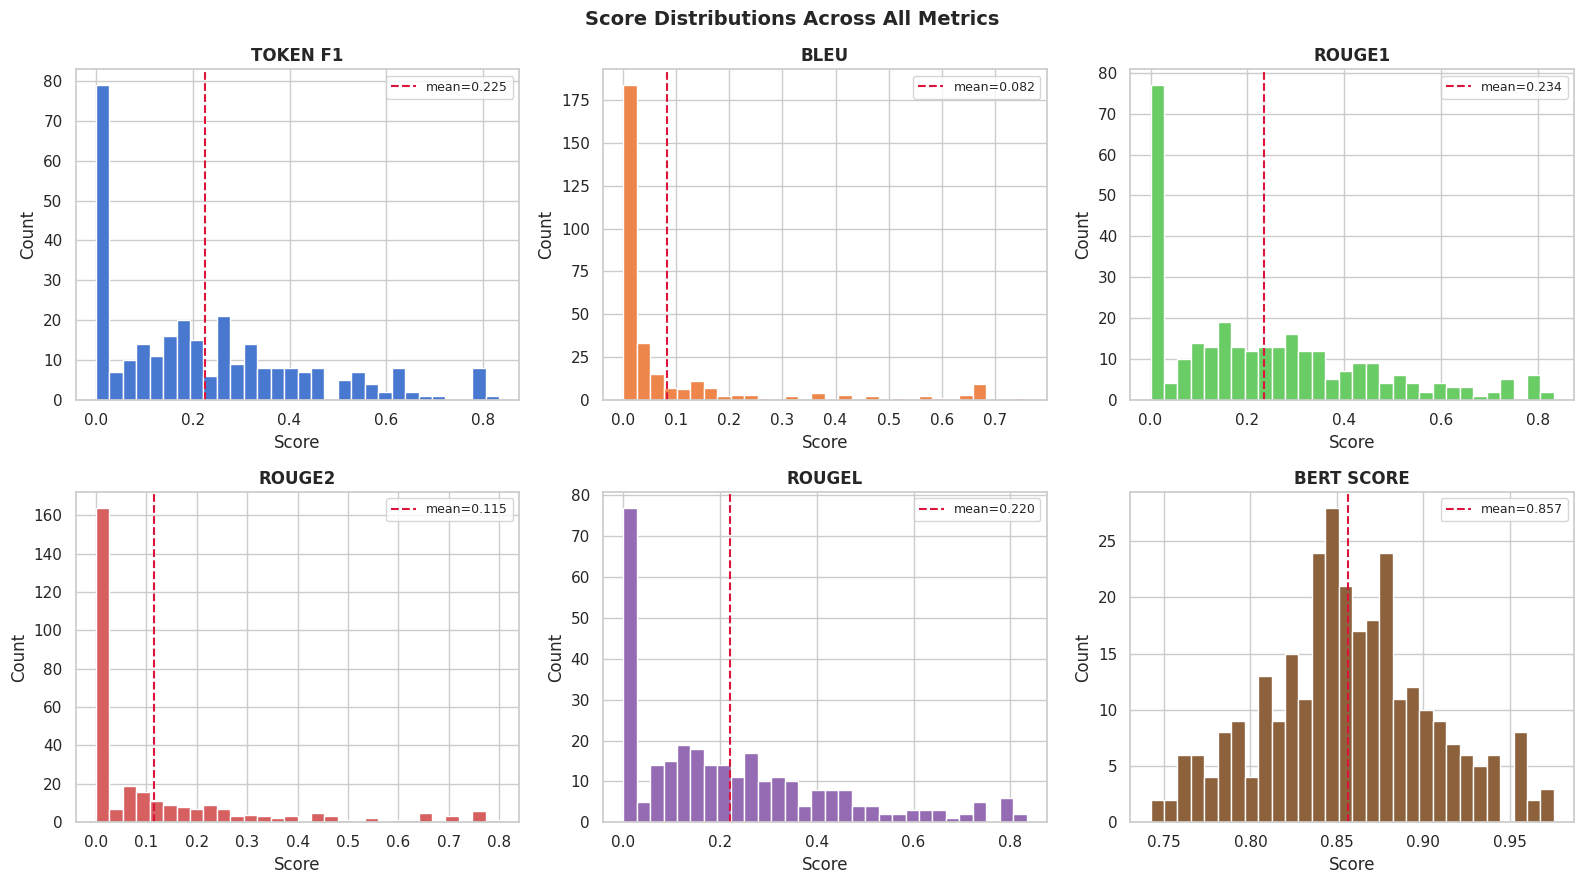

Saved: metric_distributions.png


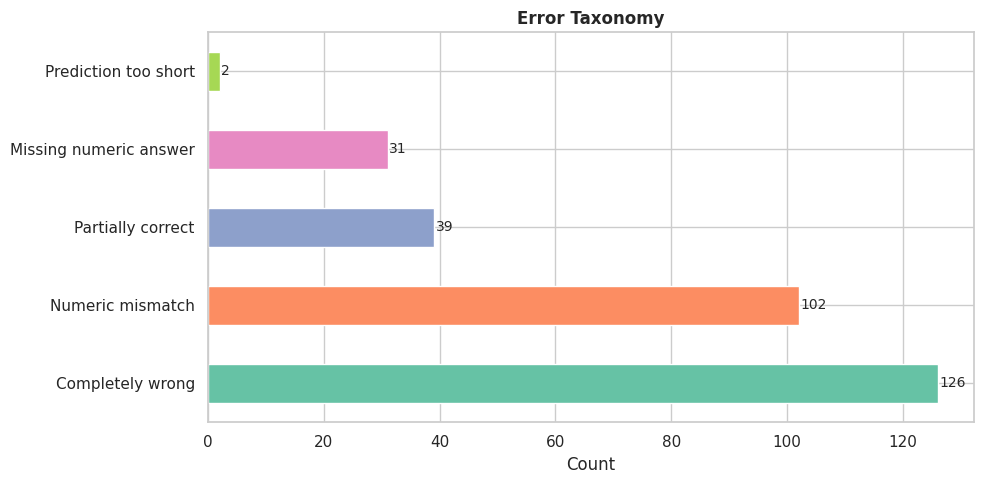

Saved: error_taxonomy.png


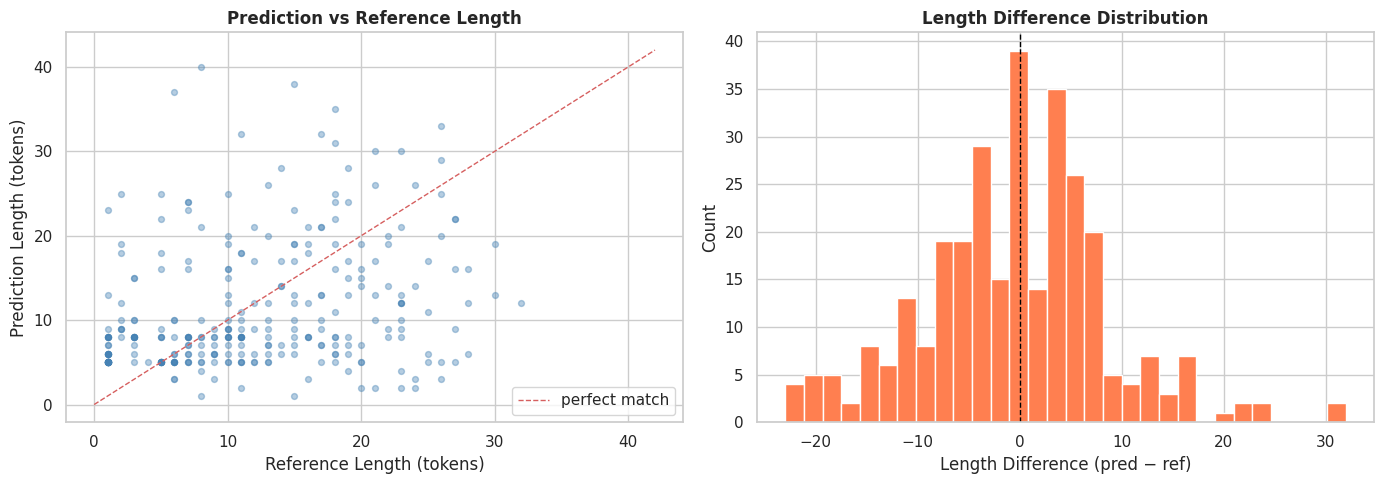

Saved: length_analysis.png


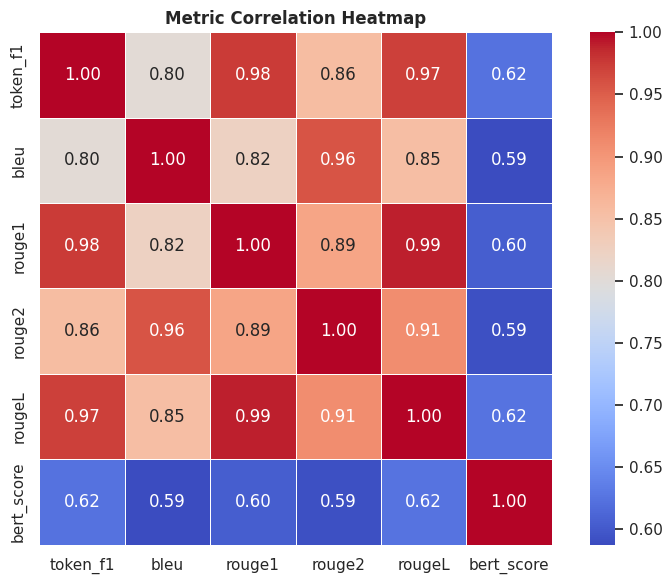

Saved: metric_correlation.png


/tmp/ipykernel_2328/385273157.py:374: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x="error_type", y="token_f1",


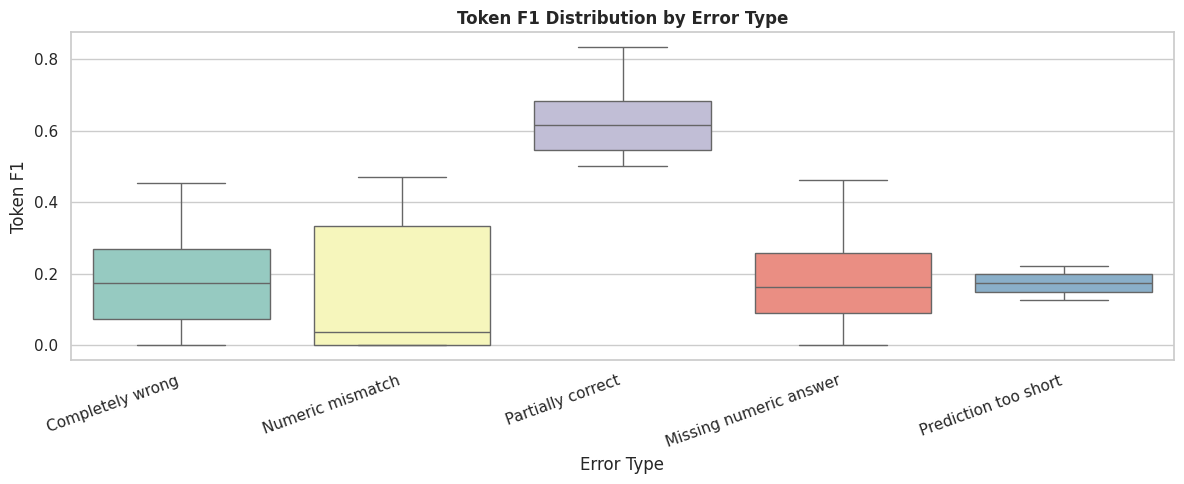

Saved: f1_by_error_type.png

FINAL SUMMARY
                Mean     Std  Median
Metric                              
Exact Match   0.0000  0.0000  0.0000
Token F1      0.2250  0.2106  0.1868
BLEU          0.0821  0.1636  0.0137
ROUGE-1       0.2339  0.2156  0.1952
ROUGE-2       0.1151  0.1889  0.0000
ROUGE-L       0.2201  0.2122  0.1714
BERTScore F1  0.8566  0.0481  0.8539

All outputs saved to: /kaggle/working/instructblip_lora_out/eval_results


In [5]:
# =============================================================
# InstructBLIP LoRA — Full Evaluation Suite
# Covers:
#   A) Metrics       : Exact Match, Token F1, BLEU, ROUGE, BERTScore
#   B) Qualitative   : Sample inspection (correct & incorrect)
#   C) Error analysis: Failure taxonomy, length analysis, confusion
# =============================================================

import subprocess, sys

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

pip_install("rouge-score", "bert-score", "nltk", "matplotlib", "seaborn", "pandas")

import os
import re
import json
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from rouge_score import rouge_scorer
from bert_score import score as bert_score

from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
from peft import PeftModel
from datasets import Dataset

# =============================================================
# CONFIG  — adjust paths to match your training script
# =============================================================
OUT_DIR        = "/kaggle/working/instructblip_lora_out"
ADAPTER_DIR    = os.path.join(OUT_DIR, "lora_adapters")
BASE_MODEL     = "Salesforce/instructblip-flan-t5-xl"
EVAL_RESULTS   = os.path.join(OUT_DIR, "eval_results")
os.makedirs(EVAL_RESULTS, exist_ok=True)

NUM_SAMPLES    = 300      # how many eval QA pairs to run through
NUM_SHOW       = 10       # qualitative examples to display
BATCH_SIZE     = 4        # inference batch size
NUM_BEAMS      = 3
MAX_NEW_TOKENS = 48
SEED           = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# =============================================================
# 1) Load model + processor
# =============================================================
print("Loading processor and model …")
processor = InstructBlipProcessor.from_pretrained(OUT_DIR)

use_cuda = torch.cuda.is_available()
bf16_ok  = use_cuda and torch.cuda.is_bf16_supported()
dtype    = torch.bfloat16 if bf16_ok else (torch.float16 if use_cuda else torch.float32)

base = InstructBlipForConditionalGeneration.from_pretrained(
    BASE_MODEL, torch_dtype=dtype, low_cpu_mem_usage=True
)
model = PeftModel.from_pretrained(base, ADAPTER_DIR)
model.eval()
if use_cuda:
    model = model.to("cuda")
print("Model loaded.\n")

# =============================================================
# 2) eval_ds — already in memory from training, just cap it
# =============================================================
# eval_ds is assumed to be already available from the training script.
# We just cap it to NUM_SAMPLES to keep inference fast.
eval_ds = eval_ds.shuffle(seed=SEED).select(range(min(NUM_SAMPLES, len(eval_ds))))
print(f"Eval QA rows: {len(eval_ds)}\n")

# =============================================================
# 3) Run inference (batched)
# =============================================================
def run_inference(dataset, batch_size=BATCH_SIZE):
    all_preds = []
    indices   = list(range(len(dataset)))

    for start in tqdm(range(0, len(indices), batch_size), desc="Inference"):
        batch_idx = indices[start : start + batch_size]
        batch     = [dataset[i] for i in batch_idx]

        images    = [b["image"]    for b in batch]
        prompts   = [f"Question: {b['question']}\nAnswer:" for b in batch]

        inputs = processor(
            images=images, text=prompts,
            padding=True, return_tensors="pt"
        ).to(model.device)

        with torch.no_grad():
            gen_ids = model.generate(
                **inputs,
                num_beams=NUM_BEAMS,
                max_new_tokens=MAX_NEW_TOKENS,
            )

        decoded = processor.tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
        all_preds.extend([d.strip() for d in decoded])

    return all_preds

print("Running inference …")
predictions = run_inference(eval_ds)
references  = list(eval_ds["answer"])   # FIX: HF Column -> plain list (required by bert_score)
questions   = list(eval_ds["question"])  # FIX: same
print("Inference complete.\n")

# =============================================================
# 4) Text normalisation helpers
# =============================================================
def normalize(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s

preds_norm = [normalize(p) for p in predictions]
refs_norm  = [normalize(r) for r in references]

# =============================================================
# 5-A) EXACT MATCH & TOKEN F1
# =============================================================
def token_f1(pred, label):
    p_tok, l_tok = pred.split(), label.split()
    if not p_tok or not l_tok:
        return 1.0 if p_tok == l_tok else 0.0
    common    = set(p_tok) & set(l_tok)
    if not common: return 0.0
    precision = len(common) / len(p_tok)
    recall    = len(common) / len(l_tok)
    return 2 * precision * recall / (precision + recall)

exact_scores = [1.0 if p == r else 0.0 for p, r in zip(preds_norm, refs_norm)]
f1_scores    = [token_f1(p, r)          for p, r in zip(preds_norm, refs_norm)]

print(f"Exact Match : {np.mean(exact_scores):.4f}")
print(f"Token F1    : {np.mean(f1_scores):.4f}")

# =============================================================
# 5-B) BLEU  (sentence-level, smoothed)
# =============================================================
smoother    = SmoothingFunction().method1
bleu_scores = []
for pred, ref in zip(preds_norm, refs_norm):
    p_tok = pred.split()
    r_tok = ref.split()
    if not p_tok:
        bleu_scores.append(0.0)
        continue
    bleu_scores.append(
        sentence_bleu([r_tok], p_tok, smoothing_function=smoother)
    )
print(f"BLEU (avg)  : {np.mean(bleu_scores):.4f}")

# =============================================================
# 5-C) ROUGE-1 / ROUGE-2 / ROUGE-L
# =============================================================
scorer      = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
rouge1, rouge2, rougeL = [], [], []
for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    rouge1.append(scores["rouge1"].fmeasure)
    rouge2.append(scores["rouge2"].fmeasure)
    rougeL.append(scores["rougeL"].fmeasure)

print(f"ROUGE-1     : {np.mean(rouge1):.4f}")
print(f"ROUGE-2     : {np.mean(rouge2):.4f}")
print(f"ROUGE-L     : {np.mean(rougeL):.4f}")

# =============================================================
# 5-D) BERTScore  (uses DeBERTa by default; slow on CPU)
# =============================================================
print("\nComputing BERTScore (this may take a minute) …")
P, R, F1_bert = bert_score(
    predictions, references,
    lang="en",
    rescale_with_baseline=False,  # FIX: True causes TypeError on some bert-score versions
    verbose=False,
    device="cuda" if torch.cuda.is_available() else "cpu",
)
print(f"BERTScore F1: {F1_bert.mean():.4f}")
bert_scores = F1_bert.tolist()

# =============================================================
# 6) Assemble results DataFrame
# =============================================================
results_df = pd.DataFrame({
    "question"    : questions,
    "reference"   : references,
    "prediction"  : predictions,
    "exact_match" : exact_scores,
    "token_f1"    : f1_scores,
    "bleu"        : bleu_scores,
    "rouge1"      : rouge1,
    "rouge2"      : rouge2,
    "rougeL"      : rougeL,
    "bert_score"  : bert_scores,
})

results_df.to_csv(os.path.join(EVAL_RESULTS, "eval_results.csv"), index=False)
print("\nFull results saved to eval_results.csv")

# =============================================================
# 7) QUALITATIVE INSPECTION
#    Show N_SHOW samples — correct ones first, then failures
# =============================================================
print("\n" + "="*70)
print("QUALITATIVE SAMPLE INSPECTION")
print("="*70)

correct_idx   = [i for i, s in enumerate(exact_scores) if s == 1.0]
incorrect_idx = [i for i, s in enumerate(exact_scores) if s == 0.0]

show_correct   = random.sample(correct_idx,   min(NUM_SHOW // 2, len(correct_idx)))
show_incorrect = random.sample(incorrect_idx, min(NUM_SHOW // 2, len(incorrect_idx)))

for label, indices in [("✅ CORRECT", show_correct), ("❌ INCORRECT", show_incorrect)]:
    print(f"\n{'─'*60}")
    print(f"  {label} EXAMPLES")
    print(f"{'─'*60}")
    for i in indices:
        print(f"\n[{i}] Question  : {questions[i]}")
        print(f"     Reference : {references[i]}")
        print(f"     Predicted : {predictions[i]}")
        print(f"     Token F1  : {f1_scores[i]:.3f}  |  ROUGE-L: {rougeL[i]:.3f}  |  BERTScore: {bert_scores[i]:.3f}")

# =============================================================
# 8) ERROR ANALYSIS
# =============================================================

# ── 8-A  Failure taxonomy ────────────────────────────────────
def classify_error(pred, ref, f1):
    pred_n, ref_n = normalize(pred), normalize(ref)
    if pred_n == ref_n:                        return "Correct"
    if pred_n == "" or pred == "":             return "Empty prediction"
    if ref_n in pred_n:                        return "Prediction too verbose"
    if pred_n in ref_n:                        return "Prediction too short"
    if f1 >= 0.5:                              return "Partially correct"
    # Check numeric mismatch
    has_num_pred = bool(re.search(r"\d", pred_n))
    has_num_ref  = bool(re.search(r"\d", ref_n))
    if has_num_pred and has_num_ref:           return "Numeric mismatch"
    if has_num_ref and not has_num_pred:       return "Missing numeric answer"
    return "Completely wrong"

error_types = [
    classify_error(p, r, f)
    for p, r, f in zip(predictions, references, f1_scores)
]
results_df["error_type"] = error_types

error_counts = pd.Series(error_types).value_counts()
print("\n" + "="*70)
print("ERROR TAXONOMY")
print("="*70)
print(error_counts.to_string())

# ── 8-B  Prediction length vs reference length ──────────────
results_df["pred_len"] = [len(p.split()) for p in predictions]
results_df["ref_len"]  = [len(r.split()) for r in references]
results_df["len_diff"] = results_df["pred_len"] - results_df["ref_len"]

print(f"\nMean prediction length : {results_df['pred_len'].mean():.1f} tokens")
print(f"Mean reference  length : {results_df['ref_len'].mean():.1f} tokens")
print(f"Mean length difference : {results_df['len_diff'].mean():.1f} tokens")

# ── 8-C  Low-confidence samples (BERTScore < 0.3) ───────────
low_conf = results_df[
    (results_df["bert_score"] < 0.3) & (results_df["exact_match"] == 0)
].sort_values("bert_score").head(10)

print("\n" + "="*70)
print("TOP-10 HARDEST FAILURES  (lowest BERTScore)")
print("="*70)
for _, row in low_conf.iterrows():
    print(f"\n  Q  : {row['question']}")
    print(f"  Ref: {row['reference']}")
    print(f"  Pred: {row['prediction']}")
    print(f"  BERTScore={row['bert_score']:.3f}  F1={row['token_f1']:.3f}  Type={row['error_type']}")

# =============================================================
# 9) VISUALISATIONS  (saved to EVAL_RESULTS/)
# =============================================================

sns.set_theme(style="whitegrid", palette="muted")

# ── Plot 1: All metric distributions ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
metric_cols = ["token_f1", "bleu", "rouge1", "rouge2", "rougeL", "bert_score"]
colors      = sns.color_palette("muted", len(metric_cols))

for ax, col, color in zip(axes, metric_cols, colors):
    ax.hist(results_df[col], bins=30, color=color, edgecolor="white")
    ax.axvline(results_df[col].mean(), color="crimson", linestyle="--", linewidth=1.5,
               label=f"mean={results_df[col].mean():.3f}")
    ax.set_title(col.upper().replace("_", " "), fontweight="bold")
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("Score Distributions Across All Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_RESULTS, "metric_distributions.png"), dpi=150)
plt.show()
print("Saved: metric_distributions.png")

# ── Plot 2: Error taxonomy bar chart ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
error_counts.plot(kind="barh", ax=ax, color=sns.color_palette("Set2", len(error_counts)))
ax.set_xlabel("Count")
ax.set_title("Error Taxonomy", fontweight="bold")
for i, v in enumerate(error_counts):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_RESULTS, "error_taxonomy.png"), dpi=150)
plt.show()
print("Saved: error_taxonomy.png")

# ── Plot 3: Prediction length vs reference length ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(results_df["ref_len"], results_df["pred_len"],
                alpha=0.4, s=18, color="steelblue")
lim = max(results_df[["ref_len","pred_len"]].max()) + 2
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1, label="perfect match")
axes[0].set_xlabel("Reference Length (tokens)")
axes[0].set_ylabel("Prediction Length (tokens)")
axes[0].set_title("Prediction vs Reference Length", fontweight="bold")
axes[0].legend()

axes[1].hist(results_df["len_diff"], bins=30, color="coral", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Length Difference (pred − ref)")
axes[1].set_ylabel("Count")
axes[1].set_title("Length Difference Distribution", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(EVAL_RESULTS, "length_analysis.png"), dpi=150)
plt.show()
print("Saved: length_analysis.png")

# ── Plot 4: Metric correlation heatmap ───────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = results_df[metric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Metric Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_RESULTS, "metric_correlation.png"), dpi=150)
plt.show()
print("Saved: metric_correlation.png")

# ── Plot 5: F1 score by error type (box) ────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
order = error_counts.index.tolist()
sns.boxplot(data=results_df, x="error_type", y="token_f1",
            order=order, palette="Set3", ax=ax)
ax.set_xlabel("Error Type")
ax.set_ylabel("Token F1")
ax.set_title("Token F1 Distribution by Error Type", fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_RESULTS, "f1_by_error_type.png"), dpi=150)
plt.show()
print("Saved: f1_by_error_type.png")

# =============================================================
# 10) SUMMARY TABLE
# =============================================================
summary = {
    "Metric"   : ["Exact Match", "Token F1", "BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore F1"],
    "Mean"     : [
        np.mean(exact_scores), np.mean(f1_scores),
        np.mean(bleu_scores),  np.mean(rouge1),
        np.mean(rouge2),       np.mean(rougeL),
        np.mean(bert_scores),
    ],
    "Std"      : [
        np.std(exact_scores), np.std(f1_scores),
        np.std(bleu_scores),  np.std(rouge1),
        np.std(rouge2),       np.std(rougeL),
        np.std(bert_scores),
    ],
    "Median"   : [
        np.median(exact_scores), np.median(f1_scores),
        np.median(bleu_scores),  np.median(rouge1),
        np.median(rouge2),       np.median(rougeL),
        np.median(bert_scores),
    ],
}
summary_df = pd.DataFrame(summary).set_index("Metric").round(4)
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(summary_df.to_string())
summary_df.to_csv(os.path.join(EVAL_RESULTS, "summary_metrics.csv"))
print(f"\nAll outputs saved to: {EVAL_RESULTS}")